# CS5228-KDDM, 2025/26-2, Coursework 2
## CW2-2: Classification (3 marks)
#### Student Name: Lee Junyoung
#### Student Number: A0247530J

### Task: Classification of houses into 4 price classes
Datasets: cs5228-Housing.csv

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# 1. Load dataset
df = pd.read_csv('cs5228-Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,class_label
0,6510000,6670,3,1,3,yes,no,yes,no,no,0,yes,unfurnished,expensive
1,5880000,7160,3,1,1,yes,no,yes,no,no,2,yes,unfurnished,expensive
2,5873000,11460,3,1,3,yes,no,no,no,no,2,yes,semi-furnished,expensive
3,3430000,2610,3,1,2,yes,no,yes,no,no,0,yes,unfurnished,medium
4,3850000,7152,3,1,2,yes,no,no,no,yes,0,no,furnished,medium


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:

# Preprocessing
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
df['furnishingstatus'] = df['furnishingstatus'].map({'unfurnished': 1, 'semi-furnished': 2, 'furnished': 3})

X = df.drop(['price', 'class_label'], axis=1)
y = df['class_label']

# Split 90/10 with random_state=110 to maintain consistency with initial results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=110)


In [ ]:
# train and test set sizes
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 490
Testing set size: 55


### 1) Correlation Analysis
To identify discardable features, we analyze the correlation between input features and the target variable. Since `class_label` is categorical, we map it to an ordinal scale for numerical correlation calculation.

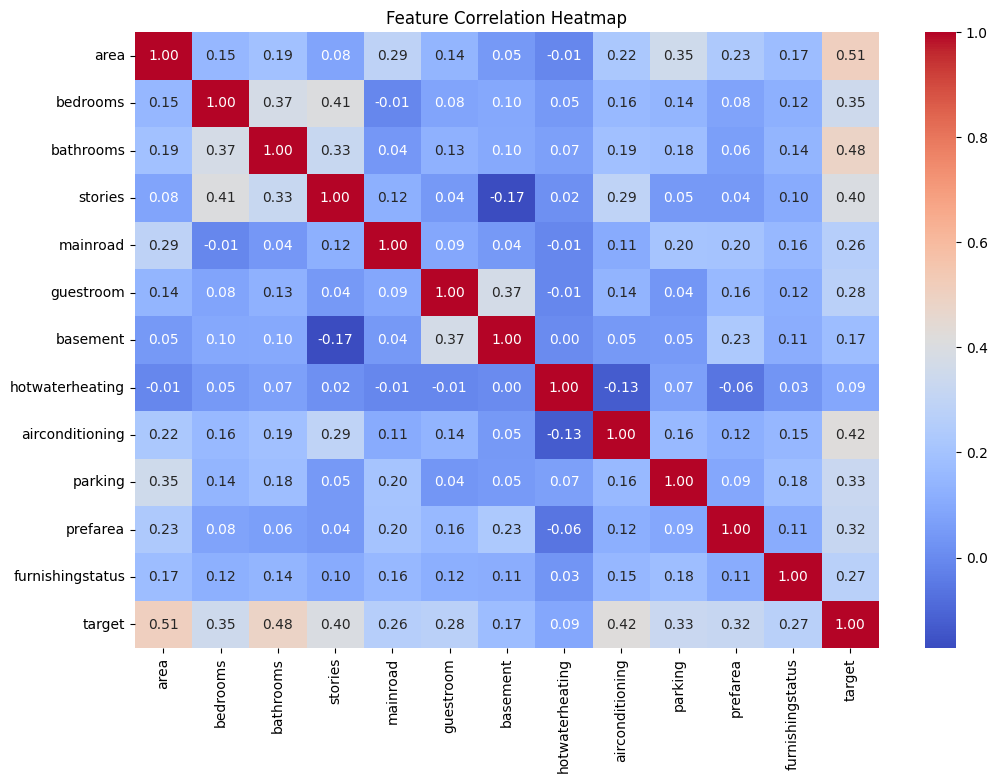

Correlation with Target Variable:
target              1.000000
area                0.508122
bathrooms           0.482903
airconditioning     0.422801
stories             0.396252
bedrooms            0.347379
parking             0.327027
prefarea            0.320129
guestroom           0.275114
furnishingstatus    0.268017
mainroad            0.258897
basement            0.171700
hotwaterheating     0.089025
Name: target, dtype: float64


In [ ]:
# Map class_label to ordinal for correlation analysis
label_order = {'cheap': 0, 'medium': 1, 'expensive': 2, 'very expensive': 3}
y_num = y.map(label_order)

# Compute correlation matrix
corr_df = X.copy()
corr_df['target'] = y_num
corr_matrix = corr_df.corr()

# Visualisation
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

print("Correlation with Target Variable:")
print(corr_matrix['target'].sort_values(ascending=False))


Based on the analysis, **`hotwaterheating`** exhibits the lowest correlation with the target variable (approx. 0.09). This indicates it provides minimal predictive signal compared to features like `area` or `bathrooms`. Discarding it helps reduce model complexity and the risk of overfitting to noise without significant loss in performance.

In [ ]:
# Drop the low-correlation feature
X_train_reduced = X_train.drop(['hotwaterheating'], axis=1)
X_test_reduced = X_test.drop(['hotwaterheating'], axis=1)


In [ ]:
def get_metrics(model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision (Macro)': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_te, y_pred, average='macro', zero_division=0)
    }


### Baseline Model - Decision Tree

In [ ]:
# decision tree
dt = DecisionTreeClassifier(random_state=110)
dt.fit(X_train_reduced, y_train)
dt_metrics = get_metrics(dt, X_test_reduced, y_test)
print("Decision Tree Metrics:", dt_metrics)

Decision Tree Metrics: {'Accuracy': 0.6181818181818182, 'Precision (Macro)': 0.438375350140056, 'Recall (Macro)': 0.4833333333333333}


In [ ]:
# hyperparameter tuning for decision tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=110)
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=110),
    param_grid=param_grid_dt,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 
)
grid_search_dt.fit(X_train_reduced, y_train)
print("Best Decision Tree Parameters:", grid_search_dt.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Decision Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
# predict with best decision tree
best_dt = grid_search_dt.best_estimator_
dt_final_metrics = get_metrics(best_dt, X_test_reduced, y_test)
print("Optimized Decision Tree Metrics:")
print("Accuracy:", dt_final_metrics['Accuracy'])
print("Precision (Macro):", dt_final_metrics['Precision (Macro)'])
print("Recall (Macro):", dt_final_metrics['Recall (Macro)'])

Optimized Decision Tree Metrics:
Accuracy: 0.7272727272727273
Precision (Macro): 0.44811776061776065
Recall (Macro): 0.45416666666666666


### Baseline Model Results
We evaluate the original baseline Random Forest.

In [ ]:
# Original Baseline: n_estimators=200, max_depth=10, class_weight='balanced'
rf_baseline = RandomForestClassifier(random_state=110, n_estimators=200, max_depth=10, class_weight='balanced')
rf_baseline.fit(X_train, y_train) # Baseline uses all features
baseline_results = get_metrics(rf_baseline, X_test, y_test)




Baseline RF Metrics: {'Accuracy': 0.7818181818181819, 'Precision (Macro)': 0.648989898989899, 'Recall (Macro)': 0.6083333333333334}


In [ ]:
print("Baseline RF Metrics:")
print("Accuracy:", baseline_results['Accuracy'])
print("Precision (Macro):", baseline_results['Precision (Macro)'])
print("Recall (Macro):", baseline_results['Recall (Macro)'])

Baseline RF Metrics:
Accuracy: 0.7818181818181819
Precision (Macro): 0.648989898989899
Recall (Macro): 0.6083333333333334


### 2) Extensive Hyperparameter Optimization
We conduct a broad `GridSearchCV` to find the optimal configuration for the Random Forest model. We optimize for `accuracy` while using `StratifiedKFold` to ensure robust validation across the imbalanced classes.

In [ ]:
# Define an extensive search grid
param_grid = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True, False]
}

# search
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=110)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=110),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_reduced, y_train)

best_rf = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)

# Evaluate Optimized Model
optimized_results = get_metrics(best_rf, X_test_reduced, y_test)


Fitting 5 folds for each of 3456 candidates, totalling 17280 fits

Best Parameters Found: {'bootstrap': True, 'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


### Comparison with Baseline
Comparing the performance of the baseline model versus our optimized model.

In [ ]:
comparison_df = pd.DataFrame([baseline_results, optimized_results], 
                             index=['Baseline RF', 'Optimized RF'])
print(comparison_df)


              Accuracy  Precision (Macro)  Recall (Macro)
Baseline RF   0.781818           0.648990        0.608333
Optimized RF  0.781818           0.519444        0.491667


### 3) Final Confusion Matrix Visualisation
Visualizing the classification performance of the best model across the 4 price classes.

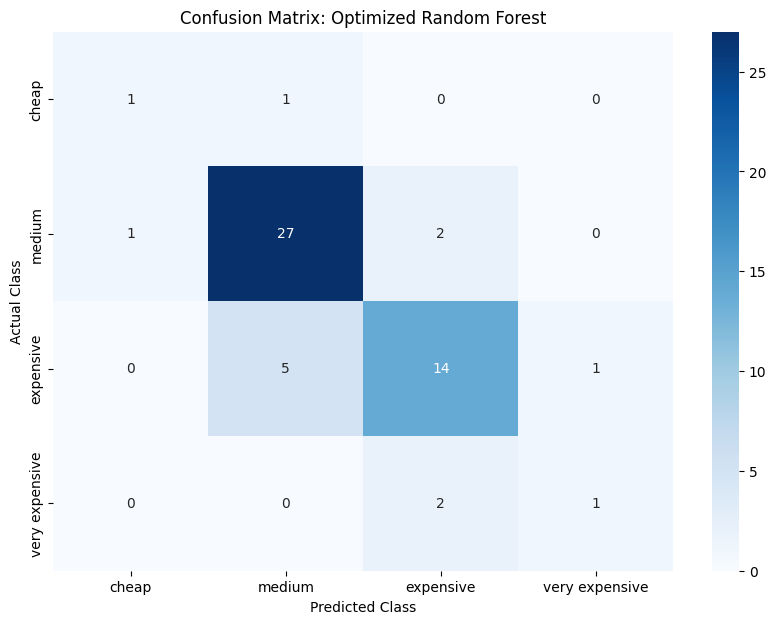

In [ ]:
# Final Labels
labels = ['cheap', 'medium', 'expensive', 'very expensive']

# Confusion Matrix for Best Model (rf baseline with full features)
y_pred_final = rf_baseline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final, labels=labels)

# Plotting with Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix: Optimized Random Forest')
plt.show()


In [ ]:

# print precision, recall, accuracy for best model (rf baseline with full features)
print("Baseline RF Metrics:")
print(f"Accuracy: {baseline_results['Accuracy']:.4f}")
print(f"Precision (Macro): {baseline_results['Precision (Macro)']:.4f}")
print(f"Recall (Macro): {baseline_results['Recall (Macro)']:.4f}")



Baseline RF Metrics:
Accuracy: 0.7818
Precision (Macro): 0.6490
Recall (Macro): 0.6083
